In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
from src.utils import *

load_dotenv()

True

In [2]:
DATA_DIR = os.getenv("DATA_FOLDER")
RESULTS_DIR = "data"

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "sbod_data_cleaned.csv"))
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161028 entries, 0 to 161027
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   Year           161028 non-null  int64
 1   Cause          161028 non-null  str  
 2   Location       161028 non-null  str  
 3   Age            161028 non-null  str  
 4   Sex            161028 non-null  str  
 5   RAG            161028 non-null  str  
 6   Measure        161028 non-null  str  
 7   Value          161028 non-null  str  
 8   Small numbers  161028 non-null  str  
dtypes: int64(1), str(8)
memory usage: 11.1 MB


In [4]:
all_locations = df["Location"].unique().tolist()

In [5]:
dfs = {}

for loc in tqdm(all_locations):
    if loc == "Scotland":
        continue
    file = f"{loc.replace(' ', '_').lower()}_analysis.xlsx"
    f_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Female")
    m_df = pd.read_excel(os.path.join(RESULTS_DIR, file), sheet_name="Male")

    cols = ["Cause", "Scotland_2019"] + [f"{loc}_{yr}" for yr in range(2014, 2020)]
    f_df = f_df[cols]
    m_df = m_df[cols]
    dfs[loc] = {"Male": m_df, "Female": f_df}

100%|██████████| 18/18 [00:01<00:00, 17.25it/s]


In [6]:
dfs["East Scotland"]["Male"]

,Cause,Scotland_2019,East Scotland_2014,East Scotland_2015,East Scotland_2016,East Scotland_2017,East Scotland_2018,East Scotland_2019
0,Ischaemic heart disease,3713,3800,3862,3622,3727,3422,3248
1,Drug use disorders,2367,1138,1174,1301,1546,1774,1766
2,Lung cancer,1749,1977,1834,1750,1772,1581,1668
3,Alzheimer's disease and other dementias,1639,1364,1632,1528,1740,1620,1622
4,Cerebrovascular disease,1516,1604,1564,1589,1595,1488,1450
...,...,...,...,...,...,...,...,...
65,Breast cancer,15,15,8,14,14,14,20
66,Other diabetes and chronic kidney disorders,4,0,1,4,0,0,0
67,Gynecological diseases,1,1,1,1,1,1,1
68,Maternal disorders,0,0,0,0,0,0,0


We calculate the following metrics for the years `2014-2018` and then use that to predict the `2019` DALY rate and see which is more predictive across all locations:

- CAGR
- TSQ2 (mean normalized)
- TSQ2 (median normalized)
- TSQ2 (interval normalized)
- TSQ2 (base normalized)
- TSQ3 (mean normalized)
- TSQ3 (median normalized)
- TSQ3 (interval normalized)
- TSQ3 (base normalized)

In [7]:
def get_accuracy(preds, actuals):
    # Calculate R^2 value
    ss_res = np.sum((preds - actuals) ** 2)
    ss_tot = np.sum((actuals - np.mean(actuals)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return r2

In [8]:
def get_lagr(row, loc, start_yr, end_yr):
    return ((row[f"{loc}_{end_yr}"] - row[f"{loc}_{start_yr}"]) / (1e-4 + row[f"{loc}_{start_yr}"])) * 100

In [9]:
for loc, df_dict in dfs.items():
    for sex, df in df_dict.items():
        # Calculate CAGR for 2014-2018 and predict 2019 value using CAGR
        df[f"{loc}_CAGR_2014_2018"] = df.apply(lambda row: get_cagr(row, loc, 2014, 2018), axis=1)
        df[f"{loc}_2019_pred_CAGR"] = df.apply(lambda row: (1 + (row[f"{loc}_CAGR_2014_2018"]/100))*row[f"{loc}_2018"], axis=1)

        # Calculate LAGR (just 2017-18) and predict 2019 value using LAGR
        df[f"{loc}_LAGR_2017_2018"] = df.apply(lambda row: get_lagr(row, loc, 2017, 2018), axis=1)
        df[f"{loc}_2019_pred_LAGR"] = df.apply(lambda row: (1 + (row[f"{loc}_LAGR_2017_2018"]/100))*row[f"{loc}_2018"], axis=1)


        # Get TSQ values for q=2 using different normalization modes and predict 2019 value using TSQ values
        for norm_mode in ["mean", "median", "interval", "base"]:
            df[f"{loc}_tsq2_{norm_mode}_2014_2018"] = df.apply(lambda row: get_tsq(list(range(2014,2019)), [row[f"{loc}_{yr}"] for yr in range(2014, 2019)], q=2, norm_mode=norm_mode), axis=1)
            df[f"{loc}_2019_pred_tsq2_{norm_mode}"] = df.apply(lambda row: (1 + (row[f"{loc}_tsq2_{norm_mode}_2014_2018"]/100))*row[f"{loc}_2018"], axis=1)

        # Get TSQ values for q=3 using different normalization modes and predict 2019 value using TSQ values
        for norm_mode in ["mean", "median", "interval", "base"]:
            df[f"{loc}_tsq3_{norm_mode}_2014_2018"] = df.apply(lambda row: get_tsq(list(range(2014,2019)), [row[f"{loc}_{yr}"] for yr in range(2014, 2019)], q=3, norm_mode=norm_mode), axis=1)
            df[f"{loc}_2019_pred_tsq3_{norm_mode}"] = df.apply(lambda row: (1 + (row[f"{loc}_tsq3_{norm_mode}_2014_2018"]/100))*row[f"{loc}_2018"], axis=1)

In [10]:
dfs["NHS Orkney"]["Male"].iloc[0]

Cause                                 Ischaemic heart disease
Scotland_2019                                            3713
NHS Orkney_2014                                          3492
NHS Orkney_2015                                          4232
NHS Orkney_2016                                          3062
NHS Orkney_2017                                          4713
NHS Orkney_2018                                          3404
NHS Orkney_2019                                          3425
NHS Orkney_CAGR_2014_2018                               -0.64
NHS Orkney_2019_pred_CAGR                           3382.2144
NHS Orkney_LAGR_2017_2018                          -27.774241
NHS Orkney_2019_pred_LAGR                         2458.564841
NHS Orkney_tsq2_mean_2014_2018                           1.97
NHS Orkney_2019_pred_tsq2_mean                      3471.0588
NHS Orkney_tsq2_median_2014_2018                         2.13
NHS Orkney_2019_pred_tsq2_median                    3476.5052
NHS Orkn

In [11]:
for loc, df_dict in dfs.items():
    with pd.ExcelWriter(os.path.join(RESULTS_DIR, f"{loc.replace(' ', '_').lower()}_analysis_2018.xlsx")) as writer:
            df_dict["Male"].to_excel(writer, sheet_name="Male", index=False)
            df_dict["Female"].to_excel(writer, sheet_name="Female", index=False)

In [12]:
len([x for x in os.listdir(RESULTS_DIR) if x.endswith("2018.xlsx")])

17

In [13]:
# Get accuracy for each gender and location for each method and normalization mode
accuracy_data = []
for loc, df_dict in dfs.items():
    for sex, df in df_dict.items():
        accuracy_row = {"Location": loc, "Sex": sex}
        accuracy_row["CAGR"] = get_accuracy(df[f"{loc}_2019_pred_CAGR"], df[f"{loc}_2019"])
        accuracy_row["LAGR"] = get_accuracy(df[f"{loc}_2019_pred_LAGR"], df[f"{loc}_2019"])
        for norm_mode in ["mean", "median", "interval", "base"]:
            accuracy_row[f"TSQ2_{norm_mode}"] = get_accuracy(df[f"{loc}_2019_pred_tsq2_{norm_mode}"], df[f"{loc}_2019"])
        for norm_mode in ["mean", "median", "interval", "base"]:
            accuracy_row[f"TSQ3_{norm_mode}"] = get_accuracy(df[f"{loc}_2019_pred_tsq3_{norm_mode}"], df[f"{loc}_2019"])
        accuracy_data.append(accuracy_row)

accuracy_df = pd.DataFrame(accuracy_data)
accuracy_df

,Location,Sex,CAGR,LAGR,TSQ2_mean,TSQ2_median,TSQ2_interval,TSQ2_base,TSQ3_mean,TSQ3_median,TSQ3_interval,TSQ3_base
0,East Scotland,Male,0.985492,9.757280e-01,0.986212,0.985865,0.986265,0.984382,0.979907,0.979352,0.980414,0.976522
1,East Scotland,Female,0.985669,9.722202e-01,0.986353,0.986386,0.986495,0.986015,0.983703,0.983772,0.983604,0.982546
2,West Scotland,Male,0.994453,9.811822e-01,0.994980,0.994935,0.994981,0.992657,0.992371,0.992279,0.992576,0.987504
3,West Scotland,Female,0.994200,9.878839e-01,0.994097,0.994083,0.994041,0.994242,0.993416,0.993378,0.993483,0.993239
4,North Scotland,Male,0.984060,9.707982e-01,0.985302,0.984446,0.985855,0.982455,0.982059,0.980864,0.982902,0.979024
5,North Scotland,Female,0.993011,-4.183769e+05,0.992772,0.992826,0.992751,0.992520,0.990506,0.990582,0.990447,0.988946
6,NHS Ayrshire and Arran,Male,0.963165,8.725713e-01,0.967155,0.967311,0.967334,0.966400,0.964501,0.963920,0.964798,0.960622
7,NHS Ayrshire and Arran,Female,0.954610,-6.701029e+08,0.954454,0.954406,0.955496,0.949824,0.946406,0.945585,0.946435,0.861777
8,NHS Borders,Male,0.812685,-2.793130e+00,0.826944,0.819932,0.827118,0.785015,0.709774,0.476762,0.719068,0.360623
9,NHS Borders,Female,0.761165,-1.065260e+00,0.799693,0.788239,0.796490,0.747591,0.692624,0.648439,0.688559,0.505094


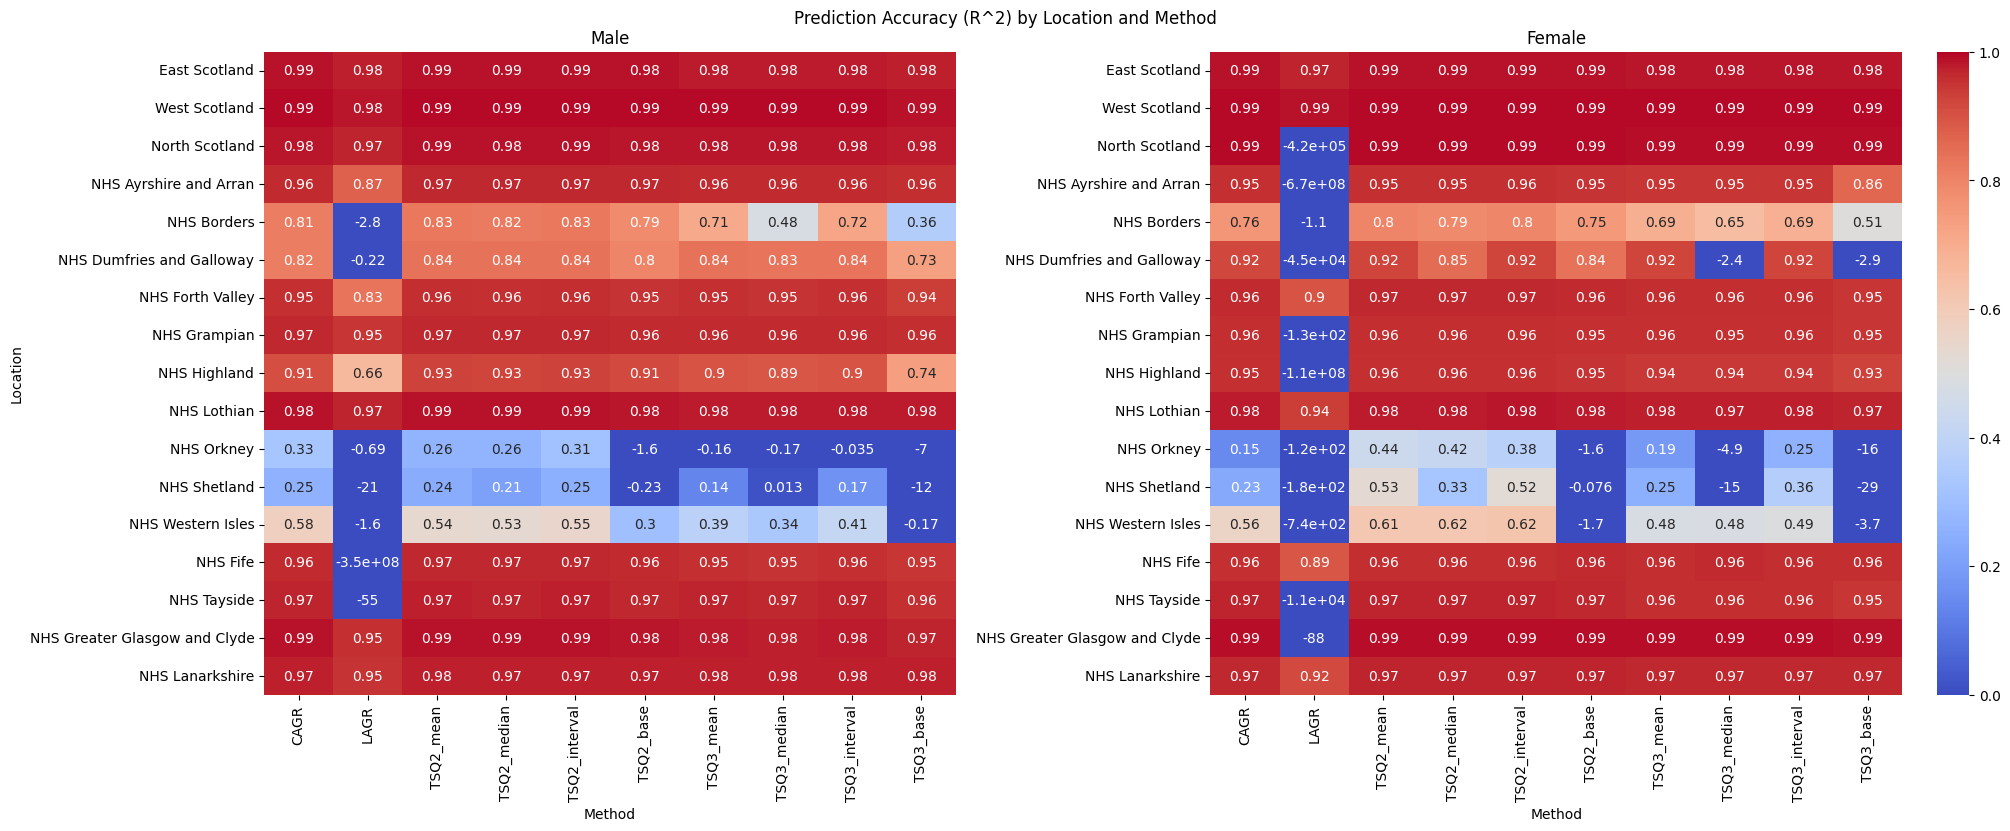

In [15]:
# Reuse acc_2017 already computed
cols = ["Location", "LAGR", "CAGR"] + [col for col in accuracy_df.columns if col.startswith("TSQ2")]

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

for ax, sex in zip(axes, ["Male", "Female"]):
    subset = accuracy_df[accuracy_df["Sex"] == sex].set_index("Location").drop(columns=["Sex"])
    sns.heatmap(
        subset,
        annot=True,
        cmap="coolwarm",
        vmin=0,
        vmax=1,
        ax=ax,
        cbar=(sex == "Female")
    )
    ax.set_title(f"{sex}")
    ax.set_xlabel("Method")
    ax.set_ylabel("Location" if sex == "Male" else "")

fig.suptitle("Prediction Accuracy (R^2) by Location and Method", y=1.02)
plt.show()

In [ ]:
accuracy_df["CAGR-LAGR"] = round(accuracy_df["CAGR"] - accuracy_df["LAGR"], 2)
for norm_mode in ["mean", "median", "interval", "base"]:
    accuracy_df[f"TSQ2_{norm_mode}-CAGR"] = round(accuracy_df[f"TSQ2_{norm_mode}"] - accuracy_df["CAGR"], 2)

cols = ["Location", "CAGR-LAGR"] + [f"TSQ2_{norm_mode}-CAGR" for norm_mode in ["mean", "median", "interval", "base"]]

# Plot as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
for ax, sex in zip(axes, ["Male", "Female"]):
    subset = accuracy_df[accuracy_df["Sex"] == sex][cols].set_index("Location")
    colormap = plt.get_cmap("coolwarm_r")
    sns.heatmap(
        subset,
        annot=True,
        cmap=colormap,
        center=0,
        vmin=-0.1,
        vmax=0.1,
        ax=ax,
        cbar=(sex == "Female")
    )
    ax.set_title(f"{sex}")
    ax.set_xlabel("Comparison")
    ax.set_ylabel("Location" if sex == "Male" else "")

fig.suptitle("Prediction Accuracy Difference by Method", y=1.02)
plt.show()